- **Learn AI/ML**
- **Machine Learning Module**
- **Simple Linear Regression**
- **Assignment No. 1**


## 1. Import Libraries

In [132]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import linear_model

## 2. Load Dataset

In [133]:
delv_logis_df = pd.read_csv('/content/Delivery_Logistics.csv')
delv_logis_df.head(5)

,delivery_id,delivery_partner,package_type,vehicle_type,delivery_mode,region,weather_condition,distance_km,package_weight_kg,delivery_time_hours,expected_time_hours,delayed,delivery_status,delivery_rating,delivery_cost
0,250.99,delhivery,automobile parts,bike,same day,west,clear,297.0,46.96,1970-01-01 00:00:00.000000008,1970-01-01 00:00:00.000000008,no,delivered,3,1632.7206
1,250.99,xpressbees,cosmetics,ev van,express,central,cold,89.6,47.39,1970-01-01 00:00:00.000000002,1970-01-01 00:00:00.000000003,no,delivered,5,640.1700
2,250.99,shadowfax,groceries,truck,two day,east,rainy,273.5,26.89,1970-01-01 00:00:00.000000010,1970-01-01 00:00:00.000000016,no,delivered,4,1448.1700
3,250.99,dhl,electronics,ev van,same day,east,cold,269.7,12.69,1970-01-01 00:00:00.000000006,1970-01-01 00:00:00.000000008,no,delivered,3,1486.5700
4,250.99,dhl,clothing,van,two day,north,foggy,256.7,37.02,1970-01-01 00:00:00.000000009,1970-01-01 00:00:00.000000016,no,delivered,4,1394.5600


In [134]:
# How many rows and columns in the dataset
delv_logis_df.shape
print(f"Initial Shape: {delv_logis_df.shape}")
print(f'Rows: {delv_logis_df.shape[0]}')
print(f'Columns: {delv_logis_df.shape[1]}')

Initial Shape: (25000, 15)
Rows: 25000
Columns: 15


In [135]:
delv_logis_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   delivery_id          25000 non-null  float64
 1   delivery_partner     25000 non-null  object 
 2   package_type         25000 non-null  object 
 3   vehicle_type         25000 non-null  object 
 4   delivery_mode        25000 non-null  object 
 5   region               25000 non-null  object 
 6   weather_condition    25000 non-null  object 
 7   distance_km          25000 non-null  float64
 8   package_weight_kg    25000 non-null  float64
 9   delivery_time_hours  25000 non-null  object 
 10  expected_time_hours  25000 non-null  object 
 11  delayed              25000 non-null  object 
 12  delivery_status      25000 non-null  object 
 13  delivery_rating      25000 non-null  int64  
 14  delivery_cost        25000 non-null  float64
dtypes: float64(4), int64(1), object(10)


## 3. Data Cleaning

In [136]:
delv_logis_df.isnull().sum()

,0
delivery_id,0
delivery_partner,0
package_type,0
vehicle_type,0
delivery_mode,0
region,0
weather_condition,0
distance_km,0
package_weight_kg,0
delivery_time_hours,0


- There is no null values in the dataset

In [137]:
delv_logis_df.columns

Index(['delivery_id', 'delivery_partner', 'package_type', 'vehicle_type',
       'delivery_mode', 'region', 'weather_condition', 'distance_km',
       'package_weight_kg', 'delivery_time_hours', 'expected_time_hours',
       'delayed', 'delivery_status', 'delivery_rating', 'delivery_cost'],
      dtype='object')

In [138]:
# Extract only 2(two) continous numeric columns from actual dataset for the assignment
slr_cols_df = delv_logis_df[['distance_km','delivery_cost']]


In [139]:
# Extract 20 rows dataset from dataset randomly for consistency and reset the index
slr_cols_df = slr_cols_df.sample(n=20, random_state=42).reset_index(drop=True)
slr_cols_df.head(5)

,distance_km,delivery_cost
0,228.6,1265.49
1,121.8,713.33
2,147.7,805.73
3,126.3,827.32
4,165.4,993.01


In [140]:
print(f"Final Shape: {slr_cols_df.shape}")
print(f'Rows: {slr_cols_df.shape[0]}')
print(f'Columns: {slr_cols_df.shape[1]}')

Final Shape: (20, 2)
Rows: 20
Columns: 2


- ## Data Visualization

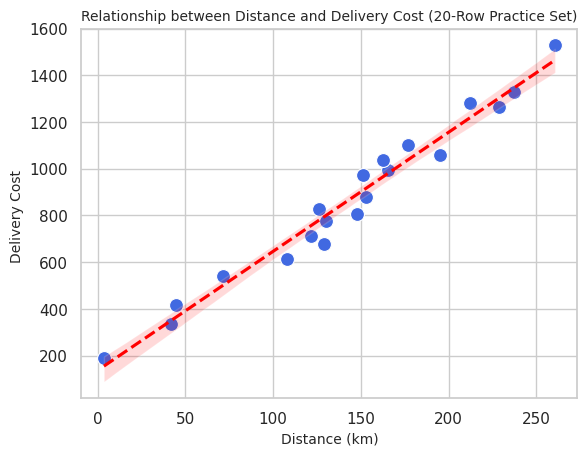

In [141]:
# Create the scatter plot
sns.scatterplot(data=slr_cols_df, x='distance_km', y='delivery_cost', color='royalblue', s=100)

# Add a regression line to visualize the trend
sns.regplot(data=slr_cols_df, x='distance_km', y='delivery_cost', scatter=False, color='red', line_kws={"linestyle":"--"})

plt.title('Relationship between Distance and Delivery Cost (20-Row Practice Set)', fontsize=10)
plt.xlabel('Distance (km)', fontsize=10)
plt.ylabel('Delivery Cost ', fontsize=10)
plt.show()

## 4. Simple Linear Regression

In [142]:
slr = linear_model.LinearRegression()
slr.fit(slr_cols_df[['distance_km']], slr_cols_df['delivery_cost'])

LinearRegression()

In [143]:
# Take 5 random sample columns
slr_cols_df.sample(5)

,distance_km,delivery_cost
2,147.7,805.73
8,128.8,677.36
18,41.6,334.31
0,228.6,1265.49
15,129.9,776.61


- ## Prediction of delivery cost with the help of trained model

In [144]:
def predict_delivery_cost(distance):
    predicted_delv_cost = slr.predict([[distance]])
    print(predicted_delv_cost)

In [145]:
predict_delivery_cost(237.3)

[1346.18649598]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [146]:
score = slr.score(slr_cols_df[['distance_km']], slr_cols_df['delivery_cost'])
coefficient = slr.coef_
intercept = slr.intercept_

In [147]:
print(f'Score: {score}')
print(f'Coefficient: {coefficient}')
print(f'Intercept: {intercept}')

Score: 0.9716594261269589
Coefficient: [5.09904226]
Intercept: 136.18376870488885


In [148]:
# Predicted cost function as manual (y = w*x + b) formula
def predict_deliv_cost_formula(distance):
    predicted_cost = coefficient * distance + intercept
    print(predicted_cost)

In [149]:
predict_deliv_cost_formula(237.3)

[1346.18649598]


In [150]:
slr_cols_df.columns

Index(['distance_km', 'delivery_cost'], dtype='object')

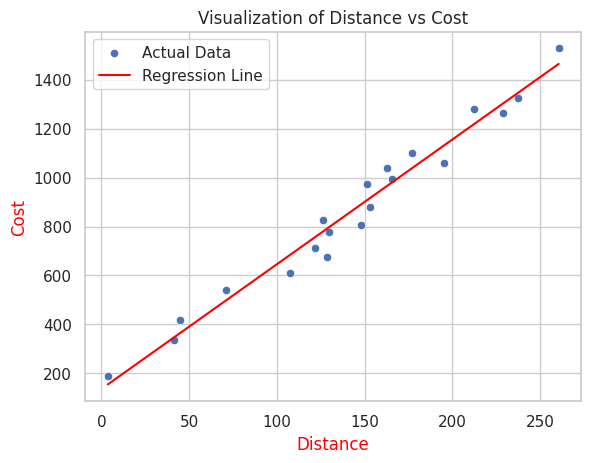

In [151]:
# Scatter plot with Seaborn
sns.scatterplot(x=slr_cols_df.distance_km, y=slr_cols_df.delivery_cost, label='Actual Data')

# Add the regression line using Seaborn's lineplot
sns.lineplot(x=slr_cols_df.distance_km, y=slr.predict(slr_cols_df[['distance_km']]), color='red', label='Regression Line')

# Customize labels and title
plt.xlabel('Distance', color='red')
plt.ylabel('Cost', color='red')
plt.title('Visualization of Distance vs Cost')
plt.legend()
plt.show()